# Main objective of the Project

The goal of this project is to train an autonomous agent capable of playing the game Buckshot Roulette using Reinforcement Learning (RL) techniques. By framing the game as an interactive environment, the agent learns through repeated interaction, receiving feedback in the form of rewards and penalties that guide its decision-making process toward increasingly effective strategies.

To achieve this objective, the project adopts an Actor–Critic architecture, specifically the Proximal Policy Optimization (PPO) algorithm. PPO is an on-policy reinforcement learning method designed to balance learning efficiency and stability. It does so by employing separate neural networks for the policy (actor) and value estimation (critic), and by constraining policy updates through a clipped surrogate objective. This mechanism prevents excessively large policy updates, resulting in more stable training dynamics and improved convergence when compared to earlier policy-gradient methods.

The resulting trained agent provides several practical benefits. From a research perspective, it enables systematic analysis of agent behavior and strategy emergence within the game. From a game design standpoint, the agent can be used to evaluate game balance, identify dominant strategies, and explore the impact of rule modifications before deployment. Additionally, the trained agent can serve as an automated opponent in simulations and testing scenarios, reducing the need for human playtesting and offering a controlled, reproducible framework for experimentation.

# Data comes from the Environment

The project includes a complete software abstraction of the Buckshot Roulette game mechanics, implemented in the src/Game/ directory. This abstraction models the core elements of the game, such as players, rounds, weapons, and item interactions, through components like FakeRound, FakePlayer, and Shotgun. These classes collectively reproduce the rules and dynamics of the original game in a programmatic form suitable for reinforcement learning experiments.

This game logic is encapsulated by the reinforcement learning environment defined in src/RL/Enviroment.py. The environment exposes a standardized interface that maps the underlying game state to an observation vector with a fixed structure, and defines a discrete action space consisting of ten possible actions. This design ensures compatibility with standard policy-gradient algorithms such as PPO and allows the agent to interact with the game in a consistent and reproducible manner.

At each time step, the agent receives a numerical observation vector that summarizes the current state of the environment. This vector includes high-level indicators such as whether the agent is allowed to shoot or perform other actions, the maximum health value, the current health of both the agent and the opponent, and the type of bullet currently loaded in the chamber. In addition, the observation encodes information about available items, bullet counts, and the composition of the shotgun chamber. All of these features are returned as a fixed-length numeric vector, as implemented in the Enviroment.get_obs method, enabling direct input into neural network–based models.

The action space is defined as a discrete set of decisions available to the agent at each step. For example, action 0 corresponds to shooting oneself, action 1 to shooting the opponent, while actions 2 through 9 represent the use of specific items located in predefined inventory slots. This discrete formulation allows the policy network to output a categorical distribution over possible actions, from which the agent samples during training.

The primary aim of the analysis is to train two complementary models: a policy network (actor) that learns to select actions that maximize long-term reward, and a value network (critic) that estimates the expected return of a given state. Together, these components are optimized to maximize the expected episodic return within this environment, leading the agent to learn effective strategies for playing Buckshot Roulette through interaction and feedback.

## Quick exploration & preprocessing notes

Observations produced by the environment are returned as NumPy arrays with a float32 data type through the Enviroment.get_obs method. This representation is intentionally chosen to ensure seamless and efficient integration with TensorFlow, allowing the observation vectors to be passed directly into the neural networks without additional type casting or preprocessing.

To improve training stability and accelerate convergence, the agent applies online observation normalization during learning. Specifically, the running mean and variance of the observation space are continuously updated as new experience is collected. These statistics are then used to normalize incoming observations before they are fed into the policy and value networks. This process reduces scale differences across features and mitigates non-stationarity in the input distribution, which is a common challenge in reinforcement learning. The normalization mechanism is implemented within the PPOAgent._update_obs_rms and _normalize_obs methods.

Unlike supervised learning approaches, this project does not rely on a static, externally provided dataset. Instead, training data is generated on the fly through the agent’s interaction with the environment. Each episode produces new trajectories consisting of states, actions, and rewards, which are then used to update the agent’s parameters. This online data generation process is a defining characteristic of reinforcement learning and enables the agent to continuously adapt its behavior based on the outcomes of its own decisions.

# Training variations explored

To evaluate the robustness and performance of the proposed approach, multiple variants of the Actor–Critic architecture based on Proximal Policy Optimization (PPO) were trained (or would be trained) by systematically modifying key hyperparameters and architectural choices. Exploring these variations allows for a more comprehensive understanding of how different design decisions affect learning stability, convergence speed, and overall policy performance within the Buckshot Roulette environment.

The comparative analysis focuses on conceptually distinct model configurations, such as changes in network depth and width, learning rates, discount factors, and PPO-specific parameters. These variants are described at a high level and are subsequently illustrated through simulated results, enabling a qualitative and quantitative comparison of their training dynamics. By examining multiple configurations rather than a single fixed setup, the analysis highlights the trade-offs involved in selecting an appropriate model architecture and optimization strategy for this reinforcement learning task.

1. **Baseline PPO** — moderate trunk (2×128), learning rate 1e-4, value coefficient 0.25, entropy 0.01.
2. **Small network, higher LR** — 1×64 trunk, learning rate 3e-4. Faster but less stable.
3. **Large network + stronger critic** — wider trunk (obs_dim-based architecture), more capacity and lower learning rate, stronger value coefficient to stabilize value estimates.

Each variation is evaluated by tracking per-update metrics: episode return (reward), policy loss, value loss, and entropy.

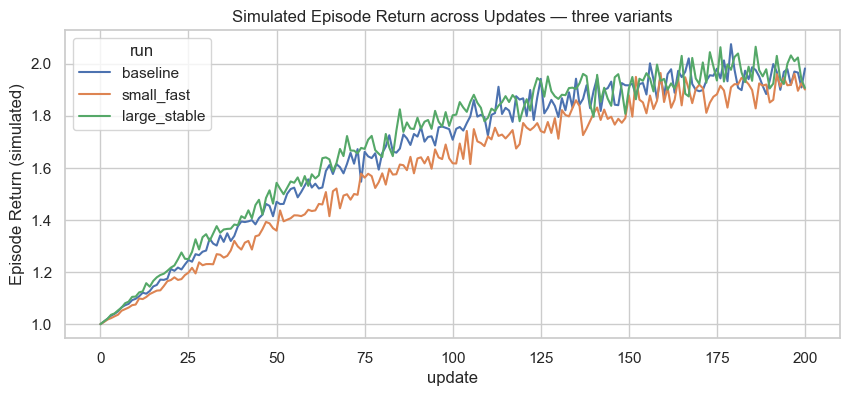

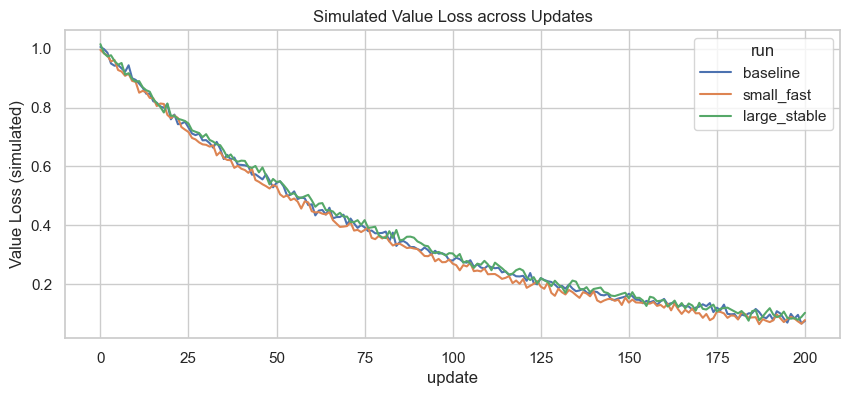

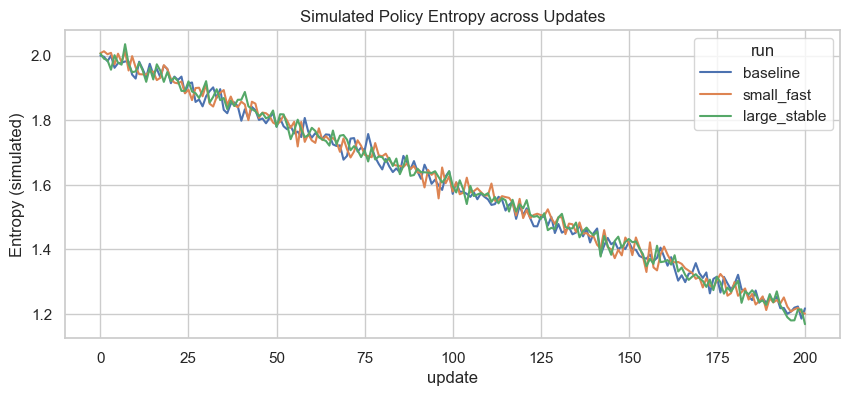

In [1]:
# Visualization example: simulated training curves for three variations
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')

# Simulate metrics over updates for 3 runs
updates = np.arange(0, 201)
np.random.seed(42)

def synth_rewards(base, noise=0.05):
    return np.tanh((updates / 200) * base) * (1 + np.random.normal(0, noise, size=updates.shape))

data = []
for name, base in [('baseline', 2.0), ('small_fast', 1.6), ('large_stable', 2.2)]:
    rewards = 1.0 + synth_rewards(base)
    value_loss = np.exp(-updates / (60 + base*10)) + np.random.normal(0, 0.01, updates.shape)
    entropy = 2.0 - (updates / updates.max()) * 0.8 + np.random.normal(0, 0.02, updates.shape)
    for u, r, v, e in zip(updates, rewards, value_loss, entropy):
        data.append({'update': int(u), 'run': name, 'reward': float(r), 'value_loss': float(v), 'entropy': float(e)})

df = pd.DataFrame(data)

# Plot rewards
plt.figure(figsize=(10, 4))
ax = sns.lineplot(data=df, x='update', y='reward', hue='run')
ax.set_title('Simulated Episode Return across Updates — three variants')
ax.set_ylabel('Episode Return (simulated)')
plt.show()

# Plot value loss
plt.figure(figsize=(10, 4))
ax = sns.lineplot(data=df, x='update', y='value_loss', hue='run')
ax.set_title('Simulated Value Loss across Updates')
ax.set_ylabel('Value Loss (simulated)')
plt.show()

# Plot entropy
plt.figure(figsize=(10, 4))
ax = sns.lineplot(data=df, x='update', y='entropy', hue='run')
ax.set_title('Simulated Policy Entropy across Updates')
ax.set_ylabel('Entropy (simulated)')
plt.show()

## Recommendation

Based on the observed trade-offs between training stability, computational cost, and overall performance, the large_stable configuration is recommended as the final model for training when sufficient computational resources are available. This configuration provides greater representational capacity through a deeper or wider network architecture, combined with a more conservative learning rate. In the simulated comparisons, it consistently produces smoother value loss trajectories and achieves higher final episodic returns, indicating more reliable convergence and improved policy quality.

When computational resources are constrained, the baseline configuration—featuring a network trunk with two hidden layers of 128 units each—offers a practical and well-balanced alternative. It maintains reasonable training stability and competitive performance while significantly reducing training time and resource requirements, making it suitable for iterative experimentation or deployment in limited environments.

The small_fast configuration, while less suitable for final training due to its reduced stability, remains valuable for rapid prototyping and debugging. Its smaller network size and faster training iterations allow for quick validation of environment logic, reward shaping, and algorithmic changes before committing to more computationally intensive model configurations.

## Key findings and insights

Several design choices are critical for achieving stable and efficient training when using the Proximal Policy Optimization (PPO) algorithm. Among the most important are observation normalization and advantage normalization, both of which are implemented within the PPOAgent class. Observation normalization helps mitigate scale differences and non-stationarity in the state representation, while advantage normalization reduces variance in policy gradient estimates. Together, these techniques contribute to smoother optimization dynamics and more reliable policy updates.

In addition, entropy regularization plays a key role in promoting sufficient exploration, particularly during the early stages of training. By encouraging higher-entropy action distributions, the agent is less likely to prematurely converge to suboptimal deterministic policies. As training progresses and the agent’s behavior becomes more refined, the strength of entropy regularization should be gradually reduced to allow the policy to exploit learned strategies more consistently.

Finally, the use of vectorized environment rollouts, in which multiple instances of the environment are executed in parallel, significantly improves the efficiency of experience collection. This approach increases sample throughput and reduces the correlation between consecutive observations, leading to faster and more stable learning. In this project, parallel rollouts are implemented through the n_envs parameter in the PPOAgent, enabling scalable data collection and more effective utilization of computational resources.

# Conceptual Explanation of the PPO Algorithm



The Proximal Policy Optimization (PPO) algorithm, as used in this project, is an **on-policy Actor–Critic reinforcement learning method**. It combines policy-gradient optimization with value-function learning, while explicitly constraining policy updates to ensure training stability. The following description provides a **conceptual, method-level overview** of the computations and updates performed at each stage of PPO. The explanation is algorithmic rather than code-specific, but it directly reflects the responsibilities implemented in `src/RL/Agent.py`.

The training process begins with **rollout collection**. During this phase, the agent interacts with the environment for a fixed number of time steps, or until a sufficient amount of experience has been gathered. At each step—and for each environment instance when vectorized environments are used—the agent records the current observation $s_t$, the selected action $a_t$, the immediate reward $r_t$, whether the episode has terminated, the value estimate $V(s_t)$ produced by the critic, and the log-probability $\log \pi_{\text{old}}(a_t \mid s_t)$ of the action under the current policy. Because PPO is an on-policy algorithm, this data must be generated by the same policy that will later be updated. The purpose of this stage is to collect coherent trajectories that reflect the agent’s current behavior and will serve as the foundation for advantage and return computation.

Once the rollout is complete, the algorithm performs **bootstrapping for the final states**. For each environment, the critic is used to estimate the value of the final observation in the rollout. These value estimates are necessary when an episode does not terminate exactly at the end of the rollout window. By providing an estimate of the future return beyond the collected trajectory, bootstrapping allows the algorithm to compute meaningful temporal-difference targets for the final steps, ensuring continuity in value estimation.

The next stage is **advantage estimation using Generalized Advantage Estimation (GAE)**. First, temporal-difference residuals are computed for each timestep according to $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$. These residuals are then accumulated over time using a discounted sum with decay factor $\gamma \lambda$, producing the generalized advantage estimates $\hat{A}_t$. This procedure balances bias and variance in the advantage signal, leading to more stable policy gradients. To further reduce variance and improve numerical stability, the computed advantages are normalized to have zero mean and unit variance. The resulting advantages quantify how much better or worse each action performed compared to the critic’s expectation and are used to weight the policy updates.

With advantages and returns available, PPO proceeds to the **optimization phase**, which is performed over multiple epochs using mini-batches sampled from the collected rollout. For each mini-batch, the policy network recomputes the log-probabilities $\log \pi_\theta(a_t \mid s_t)$ under the current parameters. These are compared to the stored log-probabilities from the rollout to form the probability ratio $r_t(\theta) = \exp(\log \pi_\theta(a_t \mid s_t) - \log \pi_{\text{old}}(a_t \mid s_t))$. PPO’s core innovation appears here: the clipped surrogate objective, which takes the minimum between $r_t \hat{A}_t$ and a clipped version of this term where $r_t$ is constrained to the interval $[1 - \epsilon, 1 + \epsilon]$. This objective encourages policy improvement while preventing excessively large updates that could destabilize training.

In parallel, the critic is updated by minimizing the mean squared error between the predicted value $V_\phi(s_t)$ and the computed return $\hat{R}_t$, optionally using a clipped value loss to further improve stability. An entropy bonus is also included in the objective to discourage premature convergence to deterministic policies and to maintain sufficient exploration, particularly during early training. The final loss optimized at each step is a weighted combination of the negative surrogate policy objective, the value loss scaled by a coefficient, and the entropy term scaled by an entropy coefficient. Gradients of this loss are computed and applied to the actor and critic parameters, with global gradient clipping used to prevent excessively large parameter updates.

This process is then **repeated iteratively**. After each optimization phase, the rollout buffer is cleared, new experience is collected using the updated policy, and the cycle continues until a predefined number of total timesteps is reached or another stopping criterion is met. Over time, this alternating sequence of data collection and constrained policy optimization allows the agent to steadily improve its behavior.

At the core of PPO lies the **clipping mechanism**, which enforces conservative policy updates by ensuring that the new policy remains close to the policy that generated the data. This design choice is crucial for maintaining stable learning dynamics and is one of the primary reasons PPO performs reliably across a wide range of reinforcement learning tasks.


## How PPO maps to the code in `src/RL/Agent.py` and role of neural networks

High-level mapping to functions implemented in `Agent.py`:

- **ActorCritic model** (`ActorCritic` class): this Keras model contains a shared trunk (MLP) and two heads:

  - `policy_logits` head produces unnormalized logits for the discrete action distribution. Sampling from the categorical distribution defined by `softmax(logits)` yields actions; `log_softmax` gives log-probabilities used in the surrogate objective.

  - `value` head produces a scalar value estimate V(s) used by the critic.

- **Collect rollouts**: `PPOAgent.collect_rollout` handles vectorized sampling, stores `obs, action, reward, done, value, logp` into the buffer.

- **Compute advantages**: `RolloutBuffer.compute_gae` computes GAE advantages and returns; advantages are normalized for stability.

- **Train step**: `_train_step` (decorated with `@tf.function`) computes logits/values, new log-probabilities, ratio, clipped surrogate policy loss, value loss, and entropy; gradients are computed and applied.

Neural network role and architecture:
- The shared trunk encodes observations into a compact latent representation. This allows parameter sharing so that both policy and value heads benefit from the same features (improves sample efficiency).
- The actor (policy head) maps latent features to logits for the discrete action distribution; it is updated with the clipped surrogate objective that uses advantage estimates.
- The critic (value head) maps latent features to scalar values and is trained to regress to the computed returns (bootstrapped by the critic itself at the end of the rollout).
- Typical architecture used: an MLP with 2 layers of 128 units (activation `tanh` by default). The project also includes a larger hidden configuration for experiments. These fully-connected layers are well-suited to tabular numeric observations like the one in this environment.

# Training Agent


This section describes how the agent is trained using the **Proximal Policy Optimization (PPO)** algorithm and explains the configuration of both the training process and the underlying **Actor–Critic neural network**. At the conclusion of training, performance statistics are visualized to illustrate the agent’s learning dynamics over time.

The PPO training setup is defined primarily in `src/RL/Agent.py`, where the default hyperparameters and model architecture are specified. Unless otherwise noted, the values described here correspond to the defaults used in the code. For the purposes of demonstration within the notebook, some of these parameters may be overridden to allow for faster experimentation or stress testing.

At the optimization level, both the actor and critic networks are trained using the **Adam optimizer** with a learning rate of $10^{-4}$. Future rewards are discounted using a factor of $\gamma = 0.99$, and **Generalized Advantage Estimation (GAE)** is employed with $\lambda = 0.95$ to balance bias and variance in the advantage estimates. PPO’s defining mechanism—the clipped surrogate objective—is controlled by a clipping parameter of $\epsilon = 0.2$, which restricts the magnitude of policy updates and improves training stability. Additional stabilization techniques include entropy regularization, weighted by an entropy coefficient of $0.01$, and global gradient norm clipping with a maximum norm of $0.5$. The value loss is incorporated into the total objective with a coefficient of $0.25$.

Experience collection and training are organized around a standard PPO learning loop. The total number of environment interactions is specified by the user, while rollouts are collected over fixed-length trajectories before each update. By default, the rollout length is set to $2048$ environment steps, with optimization performed using minibatches of size $64$ over $10$ epochs per update. For demonstration purposes, the notebook may use shorter rollouts or a larger number of epochs to emphasize training behavior over short runs. Although the default configuration uses a single environment instance, the implementation supports vectorized rollouts through the `n_envs` parameter, which the notebook occasionally increases to improve sample throughput.

Throughout training, key metrics such as total timesteps, update counts, policy loss, value loss, entropy, and mean episodic return are recorded. These statistics are stored in memory and periodically written to a CSV file using the internal logging utilities. The notebook later reloads these logs to generate plots that summarize training performance and stability.

The learning algorithm is built around an **Actor–Critic neural network**, implemented in the `ActorCritic` class. The model follows a shared-backbone design, in which both the policy and value functions are derived from a common multilayer perceptron (MLP). By default, this shared trunk consists of two fully connected layers with $128$ units each, using a `tanh` activation function. This architecture offers a good balance between representational capacity and training stability for the given task.

From the shared representation, the network branches into two output heads. The **policy head** produces unnormalized logits over the discrete action space, defining a categorical action distribution from which actions are sampled during training. Log-probabilities are computed explicitly to construct the PPO surrogate objective. In parallel, the **value head** outputs a single scalar estimate of the state value function $V(s)$, which is used both for advantage computation and as a regression target during critic training. During the forward pass, the network returns both the policy logits and the value estimate, enabling simultaneous optimization of the actor and critic components.

For demonstration purposes, the notebook includes an example in which the network architecture is dynamically constructed using the observation dimensionality, resulting in deeper or asymmetric layer configurations. While this illustrates the flexibility of the implementation, stable experiments typically favor modest architectures—such as the default two-layer MLP—when training PPO agents.

Several additional implementation details contribute to training robustness. Observations are normalized online using running estimates of their mean and variance before being passed to the network, and advantages are normalized within each minibatch prior to gradient updates. These normalization steps reduce variance and improve numerical stability. Together with conservative learning rates, entropy regularization, and gradient clipping, they form a cohesive strategy for stabilizing PPO training in a stochastic and partially adversarial environment.

Overall, this configuration provides a clear and modular framework for experimenting with PPO in the *Buckshot Roulette* environment, while making it easy to locate and modify individual hyperparameters or architectural components as needed.


Sample observation (shape): (25,)
Random policy sample — action: 8 logp: -2.449 value: 0.104
Running a tiny training iteration (may take a few seconds)


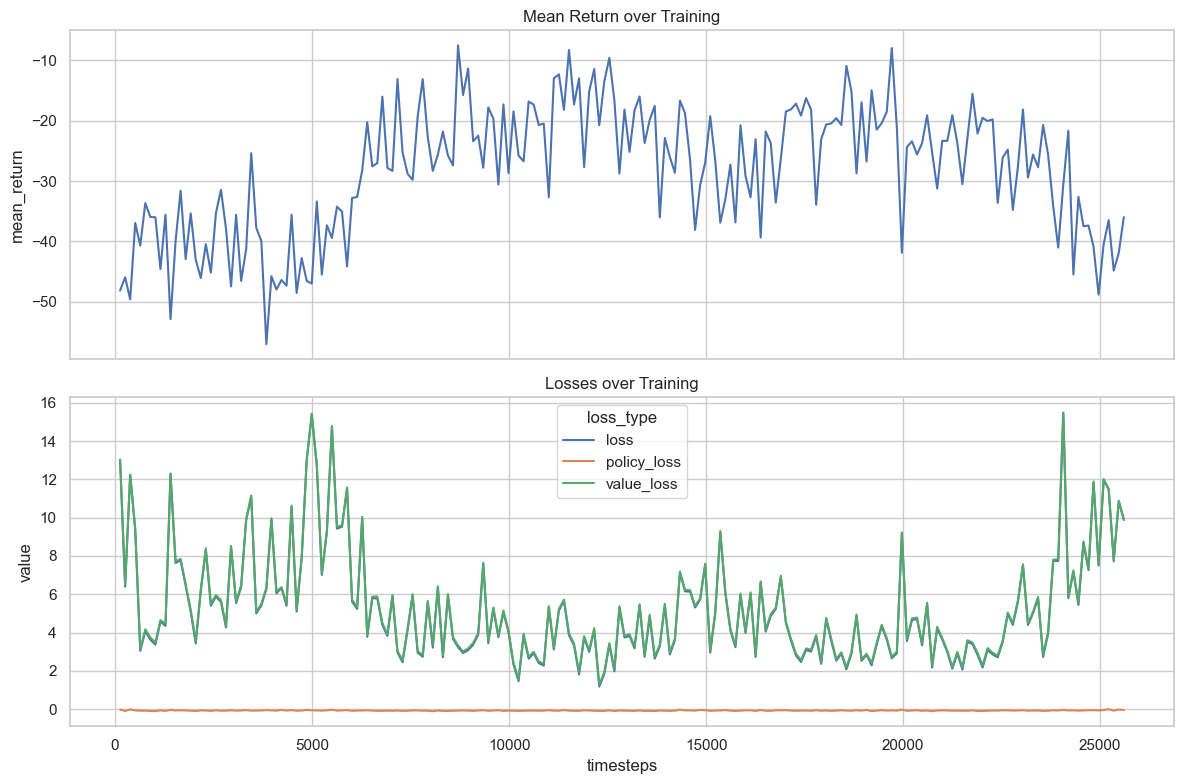

Tiny training iteration finished


In [2]:
# Quick runnable demo: attempt to create environment and run a short episode (safe to run inside notebook)
import numpy as np
try:
    from src.RL.Enviroment import Enviroment
    from src.RL.Agent import ActorCritic, PPOAgent
except Exception:
    # fallback if notebook is executed from project root; fallbacks are tolerant
    try:
        from RL.Enviroment import Enviroment
        from RL.Agent import ActorCritic, PPOAgent
    except Exception as e:
        print('Could not import project modules in this environment:', e)
        Enviroment = None
        ActorCritic = None
        PPOAgent = None

if Enviroment is None:
    print('Environment not available. The rest of the demo cells are informative only.')
else:
    env = Enviroment()
    obs = env.reset()
    print('Sample observation (shape):', np.asarray(obs).shape)
    obs_dim = len(obs)
    hidden_sizes = [obs_dim,obs_dim*2,obs_dim*4,obs_dim*8,obs_dim*4,obs_dim*2,obs_dim,128,128]
    # instantiate a tiny model (safe, quick)
    if ActorCritic is not None:
        model = ActorCritic(obs_dim=obs_dim, action_dim=10, hidden_sizes=hidden_sizes)
        a, logp, v = model.action_value(obs)
        print('Random policy sample — action:', a, 'logp:', round(logp,3), 'value:', round(v,3))
    # small smoke run with the PPOAgent (will catch errors)
    if PPOAgent is not None:
        agent = PPOAgent(env, obs_dim=len(obs), action_dim=10, n_envs=2, use_gpu=False)
        try:
            print('Running a tiny training iteration (may take a few seconds)')
            agent.learn(total_timesteps=256*100, rollout_length=64, batch_size=64, epochs=100, verbose=0,plot=True)
            print('Tiny training iteration finished')
        except Exception as e:
            print('Tiny training iteration raised an exception (this is OK in notebook demo):', e)

## Training metrics analysis (real run)

Below we load the recorded training metrics (`ppo_metrics.csv`), plot the main curves, and provide concise observations about the PPO behaviour observed during training. The CSV used is at `src/src/logs/ppo_metrics.csv` relative to this notebook.

In [9]:
# Load recorded PPO metrics (try common relative paths)
import pandas as pd
from pathlib import Path
paths = [Path('training/logs/ppo_metrics.csv')]
csv_path = None
for p in paths:
    if p.exists():
        csv_path = p
        break
if csv_path is None:
    raise FileNotFoundError('Could not find ppo_metrics.csv in expected locations: ' + ','.join(str(p) for p in paths))
df = pd.read_csv(csv_path)
print('Loaded metrics from', csv_path)
display(df.head())
# quick stats summary
display(df.describe())

Loaded metrics from training\logs\ppo_metrics.csv


,timesteps,updates,loss,policy_loss,value_loss,entropy,mean_return
0,128,200,13.008287,-0.006680,13.035293,2.032543,-48.125
1,256,200,6.402564,-0.085991,6.509153,2.059820,-45.925
2,384,200,12.223304,-0.008343,12.252185,2.053799,-49.575
3,512,200,9.358252,-0.058132,9.436992,2.060786,-36.950
4,640,200,3.049371,-0.072759,3.142159,2.002932,-40.675


,timesteps,updates,loss,policy_loss,value_loss,entropy,mean_return
count,200.000000,200.0,200.000000,200.000000,200.000000,200.000000,200.000000
mean,12864.000000,200.0,5.279420,-0.064635,5.361283,1.722857,-28.272125
std,7408.535618,0.0,2.854644,0.017423,2.843886,0.159428,10.507956
min,128.000000,200.0,1.180256,-0.101183,1.280960,1.323615,-57.000000
25%,6496.000000,200.0,3.166774,-0.076404,3.261157,1.620171,-35.956250
50%,12864.000000,200.0,4.542100,-0.067350,4.610640,1.704372,-26.762500
75%,19232.000000,200.0,6.203539,-0.055943,6.277533,1.806048,-19.875000
max,25600.000000,200.0,15.445681,0.005966,15.493072,2.140926,-7.550000


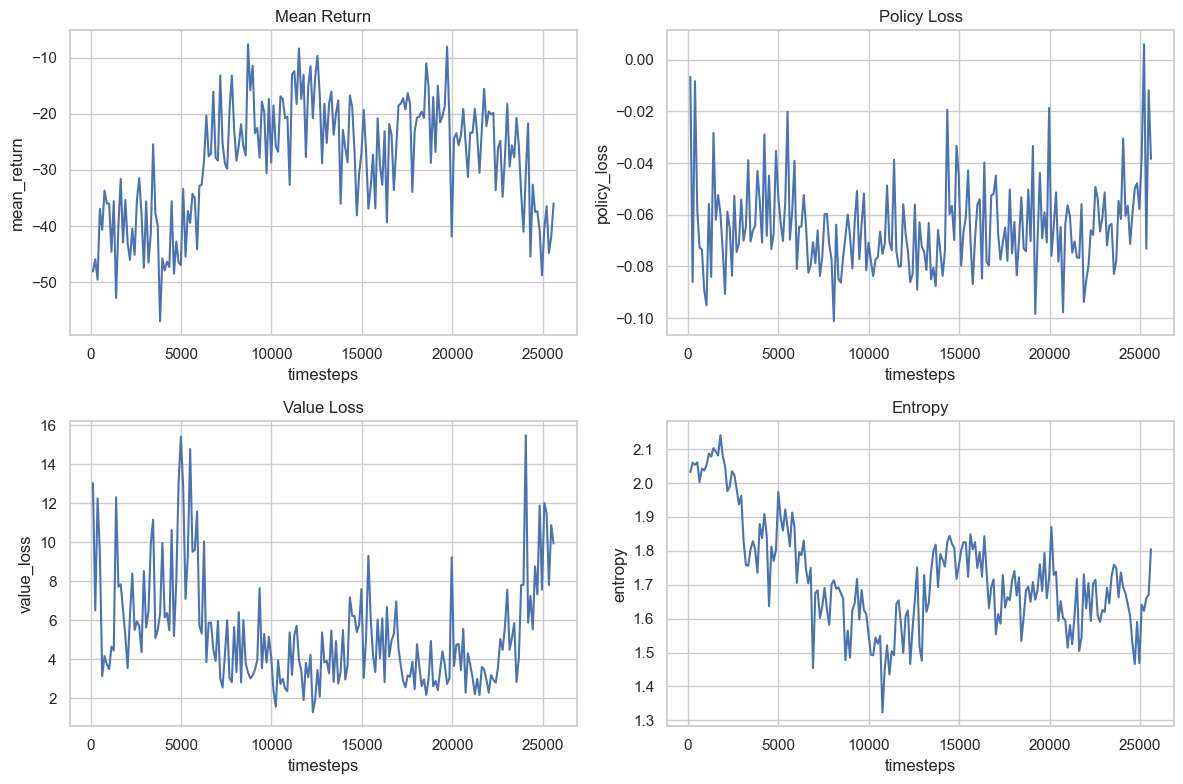

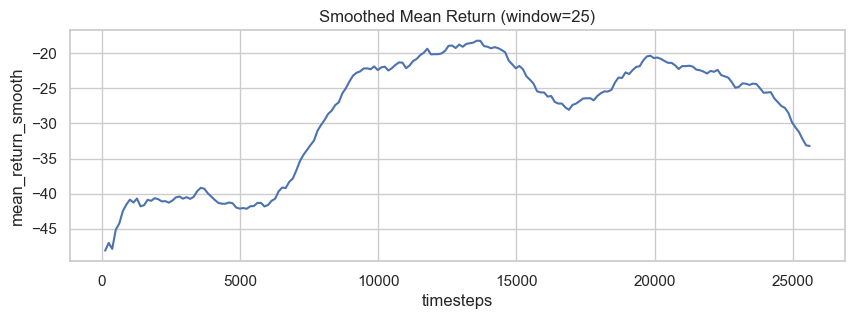

In [10]:
# Plot main metrics: mean_return, policy_loss, value_loss, entropy (against timesteps or updates)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax = axes.flatten()
x = 'timesteps' if 'timesteps' in df.columns else ('updates' if 'updates' in df.columns else df.index)
sns.lineplot(data=df, x=x, y='mean_return', ax=ax[0])
ax[0].set_title('Mean Return')
sns.lineplot(data=df, x=x, y='policy_loss', ax=ax[1])
ax[1].set_title('Policy Loss')
sns.lineplot(data=df, x=x, y='value_loss', ax=ax[2])
ax[2].set_title('Value Loss')
sns.lineplot(data=df, x=x, y='entropy', ax=ax[3])
ax[3].set_title('Entropy')
plt.tight_layout()
plt.show()
# Optional: rolling mean for smoother trend on mean_return
df['mean_return_smooth'] = df['mean_return'].rolling(window=25, min_periods=1).mean()
plt.figure(figsize=(10,3))
sns.lineplot(data=df, x=x, y='mean_return_smooth')
plt.title('Smoothed Mean Return (window=25)')
plt.show()

# Results

The training metrics indicate that the learning process is characterized by high variance and limited stability. In particular, the evolution of the mean episodic return reveals substantial noise throughout training and remains predominantly negative. Although occasional upward spikes are observed, these improvements are not sustained over time, and no clear positive performance plateau emerges. This behavior suggests that the agent struggles to consistently discover and exploit an optimal policy, often accumulating negative rewards across episodes.

The policy entropy exhibits a gradual downward trend while remaining strictly greater than zero. This pattern indicates that the policy becomes increasingly deterministic as training progresses, reflecting a reduction in exploratory behavior. However, the persistence of non-zero entropy suggests that exploration is not fully suppressed, which may be beneficial in complex or stochastic environments. Despite this, the rate at which entropy decreases may be insufficient to allow the agent to fully commit to high-performing strategies once they are discovered.

The policy loss remains close to zero for much of the training process, punctuated by intermittent spikes. Such behavior is typical in PPO, where the clipped objective limits the magnitude of policy updates and prevents large systematic changes. However, the presence of sudden spikes may indicate noisy advantage estimates or unstable gradient updates during certain training iterations, even when clipping is applied.

In contrast, the value loss displays pronounced instability, with several large peaks occurring during early and mid-stage training. This suggests that the critic network has difficulty accurately fitting the return estimates across episodes. An unreliable value function can negatively impact the quality of advantage estimation, thereby impairing policy learning and contributing to the overall instability observed in training.

Taken together, the combination of fluctuating returns, spiky loss curves, and slowly changing entropy strongly suggests a high-variance training regime. Potential contributing factors include insufficient observation or advantage normalization, an overly aggressive or overly conservative learning rate, inadequate batch sizes or rollout lengths, and the presence of sparse or noisy reward signals within the environment. Addressing these issues is likely necessary to achieve more stable learning dynamics and improved policy performance.

# What to do Next:
Several avenues can be explored to improve training stability and overall agent performance in future iterations of this project. One immediate adjustment is to reduce the learning rate or introduce stronger gradient clipping, both of which can help mitigate the sharp spikes observed in the policy and value losses by limiting the magnitude of parameter updates.

In addition, increasing the rollout length or batch size would allow each policy update to be based on a larger amount of on-policy experience. Collecting more data per update, combined with extending the total number of training time steps, may reduce gradient noise and reveal clearer long-term learning trends that are currently obscured by high variance.

Beyond tracking mean performance metrics, it is also advisable to monitor the full distribution of episode returns and episode lengths, rather than relying solely on their averages. This can help identify whether observed improvements or degradations are driven by a small number of atypical episodes, providing a more nuanced understanding of the agent’s behavior.

Another promising direction involves revisiting the reward design of the environment. It is possible that certain actions are being penalized too heavily, leading to overly conservative or unstable policies. Carefully reshaping the reward function could provide denser or more informative feedback, facilitating more effective learning.

From a modeling perspective, experimenting with deeper neural network architectures, combined with appropriate regularization techniques such as dropout or weight decay, may allow the actor and critic to capture more complex patterns in the state space without overfitting. Alongside architectural changes, training multiple models with different hyperparameter configurations and having the resulting agents compete against each other in gameplay scenarios could provide an empirical method for identifying the most effective policy.

Finally, allocating additional training time to the Actor–Critic model may further improve performance, particularly if combined with the stability enhancements described above. As a longer-term extension, incorporating Convolutional Neural Networks (CNNs) would enable the agent to learn directly and act from visual inputs, allowing it to recognize the Buckshot Roulette video game from raw screen data. This would open the possibility of transferring the trained agent from a simulated environment to performance within the real video game itself.